# Combined land cover — Beas Kund

Fuses the **perennial snow mask** with the **NDVI vegetation mask** into a single
land-cover raster, and audits the fusion.

Both inputs are built on the same 30 m UTM grid over the same AOI, so they
co-register cell-for-cell. That is a precondition, not an assumption — it is
asserted below.

The fusion is not a merge. Two questions are asked before combining:

1. **Do the masks contradict each other?** A cell called both perennial snow and
   vegetation would mean at least one mask is wrong.
2. **Can vegetation resolve cells the snow mask could not?** The snow pipeline
   leaves `undecided` and `no-data` cells. NDVI sees some of them.

Whatever survives both is reported as an explicit residue class rather than
filled in.

**Input class codes** (`perennial_class.tif`): `0` not-perennial · `1` undecided ·
`2` perennial · `4` no-data · `5` water.
**Vegetation codes** (`veg_mask.tif`): `1` vegetation · `0` seen, not vegetation ·
`-1` never seen clear.

In [2]:
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
Path("../out_combined").mkdir(exist_ok=True)

PC  = rioxarray.open_rasterio("../out_perennial/perennial_class.tif").squeeze()
cls = PC.values
veg = rioxarray.open_rasterio("../out_ndvi/veg_mask.tif").squeeze().values

assert cls.shape == veg.shape, "grids differ — masks are not on the same reference grid"
AOI = cls.size

PERENNIAL, UNDECIDED, NOT_PERENNIAL, NODATA, WATER = 2, 1, 0, 4, 5

for v, c in zip(*np.unique(cls, return_counts=True)):
    print(f"class {int(v):>2d}: {c:>7d} px ({c / AOI * 100:5.1f}%)")

class  0:   70848 px ( 52.5%)
class  1:   36324 px ( 26.9%)
class  2:    6711 px (  5.0%)
class  4:   21151 px ( 15.7%)
class  5:      22 px (  0.0%)


## 1. Do the masks contradict each other?

Perennial snow and vegetation are physically exclusive: surface that survives the
ablation minimum every year cannot also be vegetated. Any overlap is an error in
one mask or the other, so the contested count is a direct check on both.

Reported against the perennial total rather than the AOI — perennial is the much
smaller class, and a few hundred contested cells would be negligible against the
AOI while being a large fraction of the mask actually under test.

In [3]:
is_perennial = cls == PERENNIAL
is_veg       = veg == 1

contested = is_perennial & is_veg

for name, m in [("perennial", is_perennial),
                ("vegetation", is_veg),
                ("contested", contested),
                ("snow only", is_perennial & ~is_veg),
                ("vegetation only", is_veg & ~is_perennial)]:
    print(f"{name:16s}: {int(m.sum()):>7d} ({m.sum() / AOI * 100:5.2f}%)")

if is_perennial.any():
    print(f"\ncontested / perennial = {contested.sum() / is_perennial.sum() * 100:.1f}%")

perennial       :    6711 ( 4.97%)
vegetation      :   57408 (42.51%)
contested       :       0 ( 0.00%)
snow only       :    6711 ( 4.97%)
vegetation only :   57408 (42.51%)

contested / perennial = 0.0%


## 2. Rescue: resolving snow-unknowns with vegetation evidence

The snow pipeline leaves two kinds of unknown — `undecided` (seen, but the
multi-year evidence did not reach a verdict) and `no-data` (never seen clear).

A cell that NDVI **positively** calls vegetation is resolved. This is one-way:
vegetation evidence can fill a snow unknown, but a vegetation *negative* is not
evidence of snow, so `veg == 0` resolves nothing.

The split of what remains matters more than the count. `NDVI saw it and said
not-vegetation` is genuine surface ambiguity — bare ground, or snow the pipeline
could not confirm. `Neither method saw it` is an acquisition gap. They are
different problems and conflating them would hide which one this AOI actually has.

In [4]:
undecided      = cls == UNDECIDED
nodata         = cls == NODATA
unknown_before = undecided | nodata

rescue        = unknown_before & is_veg
unknown_after = unknown_before & ~rescue

pct = lambda m: f"{int(m.sum()):>6d} ({m.sum() / AOI * 100:5.2f}%)"

print(f"unknown before      : {pct(unknown_before)}")
print(f"  from undecided    : {pct(undecided & is_veg)}")
print(f"  from no-data      : {pct(nodata & is_veg)}")
print(f"  rescued total     : {pct(rescue)}")
print(f"unknown after       : {pct(unknown_after)}")

remaining_undecided = undecided & ~rescue
print(f"\nremaining undecided : {int(remaining_undecided.sum())}")
print(f"  NDVI saw, not veg : {int((remaining_undecided & (veg == 0)).sum())}   (bare, or snow not confirmed)")
print(f"  NDVI also blind   : {int((remaining_undecided & (veg == -1)).sum())}   (acquisition gap)")
print(f"remaining no-data   : {int((nodata & ~rescue).sum())}")

unknown before      :  57475 (42.56%)
  from undecided    :  24344 (18.03%)
  from no-data      :  19428 (14.39%)
  rescued total     :  43772 (32.41%)
unknown after       :  13703 (10.15%)

remaining undecided : 11980
  NDVI saw, not veg : 11977   (bare, or snow not confirmed)
  NDVI also blind   : 3   (acquisition gap)
remaining no-data   : 1723


## 3. Terrain, for validation only

Copernicus GLO-30, reprojected onto the perennial grid exactly. Used to test the
classes against terrain, not to produce them — nothing below feeds back into the
classification.

In [5]:
import pystac_client
import planetary_computer
import rioxarray.merge
from rasterio.enums import Resampling

cat = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
items = list(cat.search(collections=["cop-dem-glo-30"],
                        bbox=PC.rio.reproject("EPSG:4326").rio.bounds()).items())

# GLO-30 ships in 1x1 degree tiles; an AOI can straddle more than one
tiles = [rioxarray.open_rasterio(it.assets["data"].href, masked=True).squeeze() for it in items]
dem_raw = rioxarray.merge.merge_arrays(tiles) if len(tiles) > 1 else tiles[0]

dem = dem_raw.rio.reproject_match(PC, resampling=Resampling.bilinear)
dem.rio.to_raster("../out_combined/dem.tif")

dem_v = dem.squeeze().values
print(f"{len(items)} DEM tile(s) | grid matches: {dem.squeeze().shape == cls.shape}")
print(f"elevation: {float(np.nanmin(dem_v)):.0f}–{float(np.nanmax(dem_v)):.0f} m")

1 DEM tile(s) | grid matches: True
elevation: 2516–5870 m


### 3a. Does the classification stratify by elevation?

If the classes are right, they should order themselves up the mountain:
vegetation lowest, perennial snow highest, and the unresolved residue between
them — the transition belt where neither method is confident.

Two forms of the test are reported. The **literal** one uses the vegetation
maximum and fails: a handful of high outlier cells push it above the residue
mean. The **robust** one uses the vegetation p90 and holds. The failure is
reported rather than dropped — the ordering is a tendency, not a hard boundary,
and only the robust form should be relied on.

In [6]:
residue = unknown_after

for name, m in [("vegetation", is_veg), ("residue", residue), ("perennial", is_perennial)]:
    e = dem_v[m]
    print(f"{name:12s}: median {np.nanmedian(e):5.0f}  mean {np.nanmean(e):5.0f}  "
          f"p10 {np.nanpercentile(e, 10):5.0f}  p90 {np.nanpercentile(e, 90):5.0f}")

veg_max, veg_p90 = np.nanmax(dem_v[is_veg]), np.nanpercentile(dem_v[is_veg], 90)
res_mean, per_mean = np.nanmean(dem_v[residue]), np.nanmean(dem_v[is_perennial])

print(f"\nliteral (veg_max {veg_max:.0f} < residue {res_mean:.0f} < perennial {per_mean:.0f}): "
      f"{'HOLDS' if veg_max < res_mean < per_mean else 'FAILS'}")
print(f"robust  (veg_p90 {veg_p90:.0f} < residue {res_mean:.0f} < perennial {per_mean:.0f}): "
      f"{'HOLDS' if veg_p90 < res_mean < per_mean else 'FAILS'}")

vegetation  : median  3619  mean  3612  p10  2964  p90  4239
residue     : median  4545  mean  4562  p10  4147  p90  5012
perennial   : median  4954  mean  4961  p10  4733  p90  5228

literal (veg_max 5510 < residue 4562 < perennial 4961): FAILS
robust  (veg_p90 4239 < residue 4562 < perennial 4961): HOLDS


### 3b. What kind of terrain stays unresolved?

Slope and northness per class. Northness is `cos(aspect)`: `+1` north-facing and
shadowed in the northern hemisphere, `-1` south-facing and sunlit.

This is where the residue stops being a leftover and becomes explainable.

In [7]:
res_x, res_y = abs(dem.rio.transform()[0]), abs(dem.rio.transform()[4])
gy, gx = np.gradient(dem_v, res_y, res_x)

slope     = np.degrees(np.arctan(np.hypot(gx, gy)))
aspect    = np.degrees(np.arctan2(-gx, gy)) % 360
northness = np.cos(np.radians(aspect))

bare = (cls == NOT_PERENNIAL) & ~is_veg

for name, m in [("vegetation", is_veg), ("bare rock/scree", bare),
                ("perennial", is_perennial), ("residue", residue)]:
    print(f"{name:16s}: slope median {np.nanmedian(slope[m]):4.1f}  "
          f"p90 {np.nanpercentile(slope[m], 90):4.1f}   "
          f"northness median {np.nanmedian(northness[m]):+.2f}")

vegetation      : slope median 33.1  p90 49.5   northness median -0.34
bare rock/scree : slope median 35.5  p90 52.6   northness median -0.28
perennial       : slope median 16.6  p90 33.3   northness median -0.25
residue         : slope median 37.0  p90 53.8   northness median +0.17


## 4. The combined raster

`0` bare rock/scree · `1` vegetation · `2` perennial snow/ice · `3` water ·
`4` residue · `255` fill.

Precedence is deliberate: perennial and water are asserted classes and are never
overwritten; vegetation takes what is left; residue is what nothing could claim.
It stays a class of its own rather than being folded into bare ground, because
"nothing resolved this" and "this is bare" are different statements.

In [8]:
BARE, VEG, PER, WAT, RES = 0, 1, 2, 3, 4

is_water = cls == WATER
veg_all  = (is_veg & ~is_perennial & ~is_water) | rescue

lc = np.full(cls.shape, 255, dtype="uint8")
lc[bare]         = BARE
lc[veg_all]      = VEG
lc[is_perennial] = PER
lc[is_water]     = WAT
lc[residue]      = RES

PC.copy(data=lc).rio.to_raster("../out_combined/landcover_combined.tif")

for code, name in [(BARE, "bare rock/scree"), (VEG, "vegetation"), (PER, "perennial"),
                   (WAT, "water"), (RES, "residue"), (255, "fill")]:
    n = int((lc == code).sum())
    print(f"{code:>3d}  {name:16s}: {n:>7d} ({n / AOI * 100:5.2f}%)")

  0  bare rock/scree :   57212 (42.36%)
  1  vegetation      :   57408 (42.51%)
  2  perennial       :    6711 ( 4.97%)
  3  water           :      22 ( 0.02%)
  4  residue         :   13703 (10.15%)
255  fill            :       0 ( 0.00%)


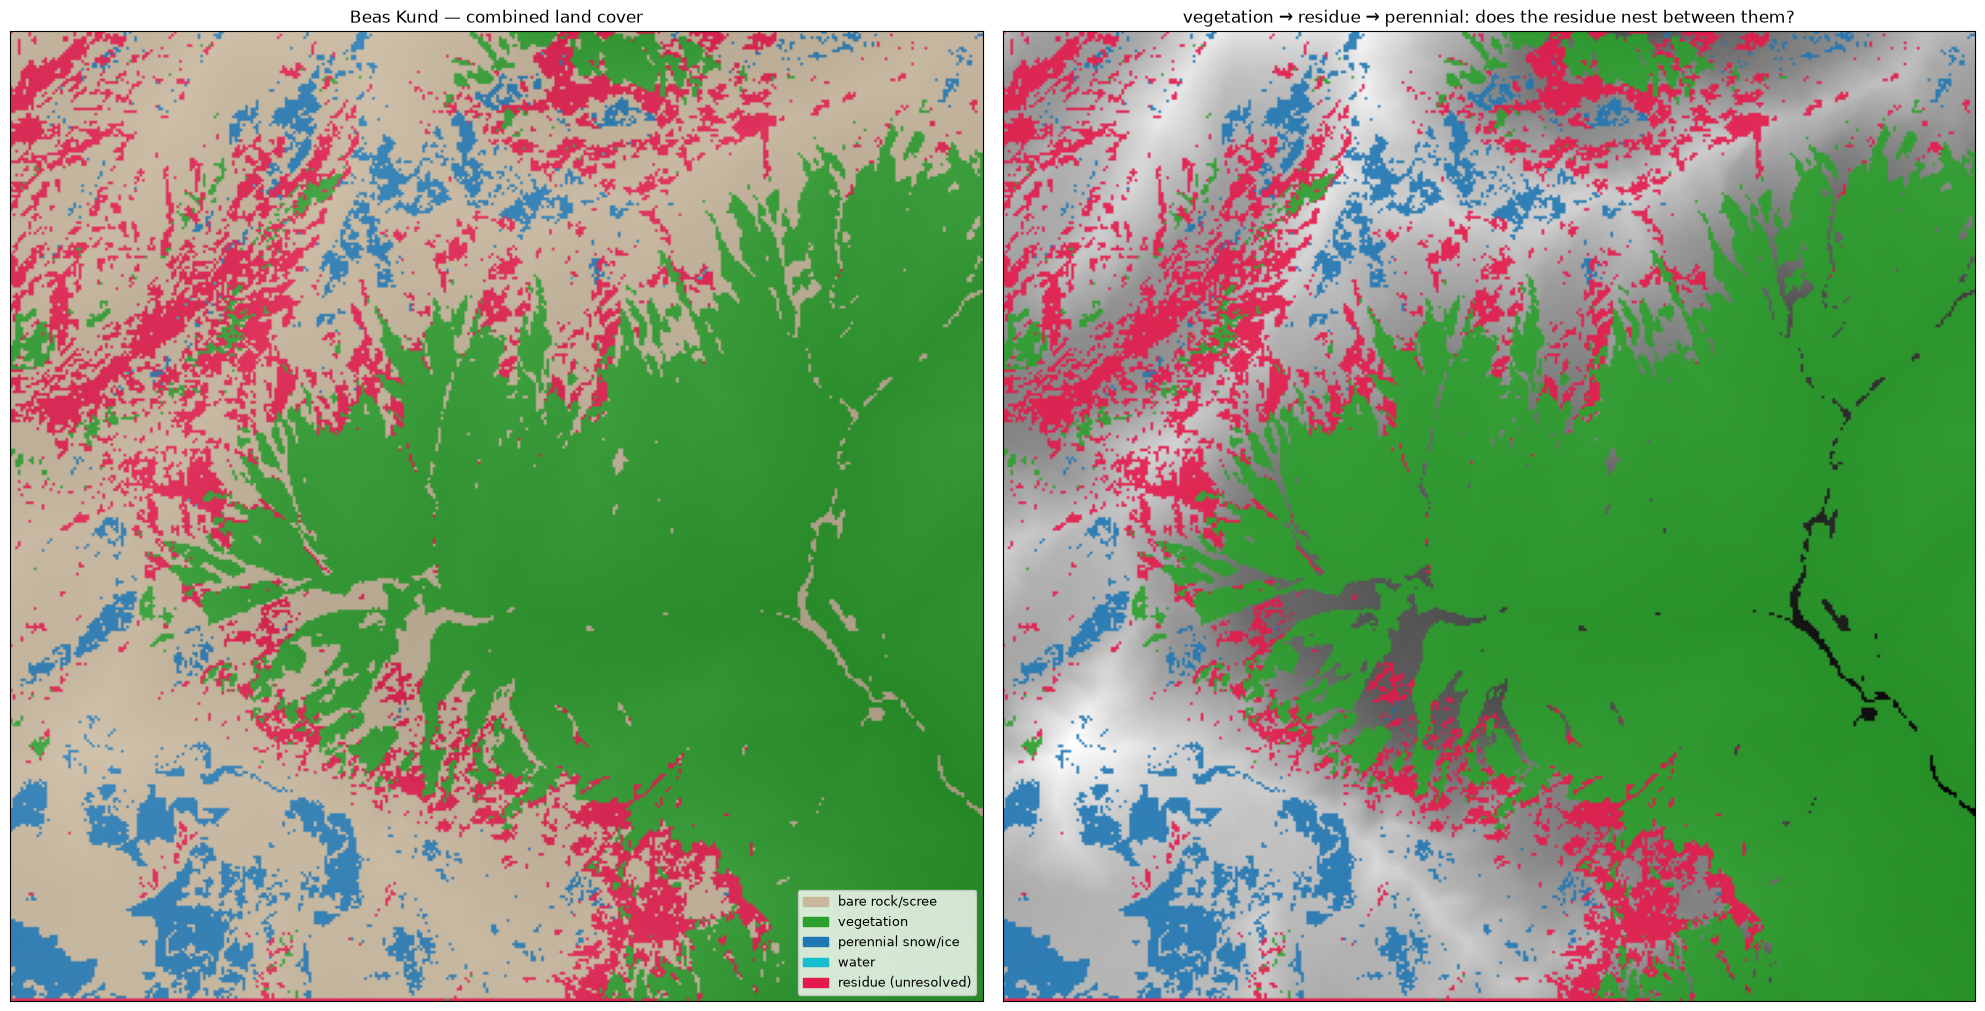

In [9]:
palette = {BARE: ("#c9b79c", "bare rock/scree"),
           VEG:  ("#2ca02c", "vegetation"),
           PER:  ("#1f77b4", "perennial snow/ice"),
           WAT:  ("#17becf", "water"),
           RES:  ("#e6194B", "residue (unresolved)")}

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(dem_v, cmap="gray")
ax[0].imshow(np.where(lc < 5, lc, np.nan),
             cmap=mcolors.ListedColormap([palette[i][0] for i in range(5)]),
             vmin=-0.5, vmax=4.5, alpha=0.85)
ax[0].set_title("Beas Kund — combined land cover")
ax[0].legend(handles=[mpatches.Patch(color=c, label=l) for c, l in palette.values()],
             loc="lower right", fontsize=9)

# residue should sit as a belt between vegetation and perennial, not scattered
zone = np.full(cls.shape, np.nan)
zone[veg_all]      = 0
zone[residue]      = 1
zone[is_perennial] = 2
ax[1].imshow(dem_v, cmap="gray")
ax[1].imshow(zone, cmap=mcolors.ListedColormap(["#2ca02c", "#e6194B", "#1f77b4"]),
             vmin=-0.5, vmax=2.5, alpha=0.9)
ax[1].set_title("vegetation → residue → perennial: does the residue nest between them?")

for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout()
plt.show()

## What this does not resolve

The residue is not noise and it is not evenly distributed. It is the steepest
class in the AOI and the only north-facing one — steep shadowed faces, where
optical sensors have the least signal and both masks abstain for the same
physical reason. Reporting it as its own class keeps that visible instead of
burying it in bare ground.

Scope limits are in the project README. In short: bare ground here is genuinely
rock and scree because the AOI is high alpine(one exception which is out of scope is moraine), so no urban or agricultural
separation is attempted, and no distinction is made between moraine and bedrock.